In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Q1 A a)

In [23]:
data=[
    (180,7,"Apple"),
    (200,6,"Apple"),
    (150,4,"Orange"),
    (170,5,"Orange"),
    (160,6,"Apple"),
    (140,3,"Orange")
]

new_weight=165
new_sweetness=5.5

distances=[]

for weight,sweetness,label in data:

    distance=math.sqrt(
        (weight-new_weight)**2+
        (sweetness-new_sweetness)**2
    )

    distances.append((distance,label))

distances.sort()

k=3

neighbors=distances[:k]

apple=0
orange=0

for distance,label in neighbors:

    if label=="Apple":
        apple+=1
    else:
        orange+=1

if apple>orange:
    result="Apple"
else:
    result="Orange"

print("Nearest Neighbors:")
for distance,label in neighbors:
    print(label,distance)

print("Predicted Fruit:",result)

Nearest Neighbors:
Apple 5.024937810560445
Orange 5.024937810560445
Apple 15.074813431681335
Predicted Fruit: Apple


# b)

In [24]:
for weight,sweetness,label in data:

    euclidean=math.sqrt(
        (weight-new_weight)**2+
        (sweetness-new_sweetness)**2
    )

    manhattan=(
        abs(weight-new_weight)+
        abs(sweetness-new_sweetness)
    )

    p=3

    minkowski=(
        abs(weight-new_weight)**p+
        abs(sweetness-new_sweetness)**p
    )**(1/p)

    print("\nFruit:",label)
    print("Euclidean:",euclidean)
    print("Manhattan:",manhattan)
    print("Minkowski:",minkowski)


Fruit: Apple
Euclidean: 15.074813431681335
Manhattan: 16.5
Minkowski: 15.00499833425864

Fruit: Apple
Euclidean: 35.00357124637428
Manhattan: 35.5
Minkowski: 35.00003401357238

Fruit: Orange
Euclidean: 15.074813431681335
Manhattan: 16.5
Minkowski: 15.00499833425864

Fruit: Orange
Euclidean: 5.024937810560445
Manhattan: 5.5
Minkowski: 5.001666111419547

Fruit: Apple
Euclidean: 5.024937810560445
Manhattan: 5.5
Minkowski: 5.001666111419547

Fruit: Orange
Euclidean: 25.124689052802225
Manhattan: 27.5
Minkowski: 25.008330557097732


# d)

In [25]:
for k in [1,3,5]:

    apple=0
    orange=0

    for distance,label in distances[:k]:
        if label=="Apple":
            apple+=1
        else:
            orange+=1

    if apple>orange:
        result="Apple"
    else:
        result="Orange"

    print("k =",k,"Apple =",apple,"Orange =",orange,"Prediction =",result)

k = 1 Apple = 1 Orange = 0 Prediction = Apple
k = 3 Apple = 2 Orange = 1 Prediction = Apple
k = 5 Apple = 2 Orange = 3 Prediction = Orange


# e)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

X=np.array([
    [180,7],
    [200,6],
    [150,4],
    [170,5],
    [160,6],
    [140,3]
])

y=np.array([
    "Apple",
    "Apple",
    "Orange",
    "Orange",
    "Apple",
    "Orange"
])

knn=KNeighborsClassifier(n_neighbors=3)

knn.fit(X,y)

print("Sklearn Prediction:",knn.predict([[165,5.5]])[0])

Sklearn Prediction: Orange


# f)

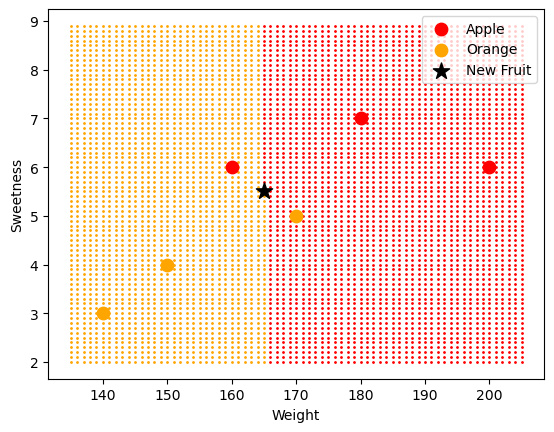

In [27]:
x=np.arange(135,206,1)
y_grid=np.arange(2,9,0.1)

for i in x:
    for j in y_grid:
        pred=knn.predict([[i,j]])[0]

        if pred=="Apple":
            plt.scatter(i,j,color="red",s=1)
        else:
            plt.scatter(i,j,color="orange",s=1)

plt.scatter(X[y=="Apple",0],X[y=="Apple",1],color="red",s=80,label="Apple")
plt.scatter(X[y=="Orange",0],X[y=="Orange",1],color="orange",s=80,label="Orange")

plt.scatter(165,5.5,color="black",marker="*",s=150,label="New Fruit")

plt.xlabel("Weight")
plt.ylabel("Sweetness")
plt.legend()
plt.show()

# Q1 B

Prediction: Orange


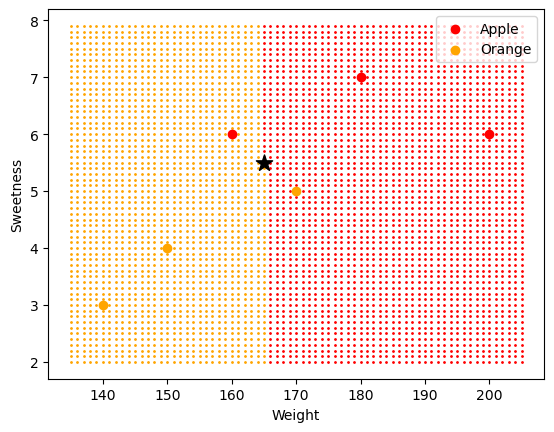


 euclidean
Distances: [ 5.02493781  5.02493781 15.07481343]
Neighbors: ['Orange' 'Apple' 'Orange']
Prediction: Orange

 manhattan
Distances: [ 5.5  5.5 16.5]
Neighbors: ['Orange' 'Apple' 'Orange']
Prediction: Orange

 minkowski
Distances: [ 5.00166611  5.00166611 15.00499833]
Neighbors: ['Orange' 'Apple' 'Orange']
Prediction: Orange


In [28]:
from sklearn.neighbors import KNeighborsClassifier

X=np.array([
    [180,7],
    [200,6],
    [150,4],
    [170,5],
    [160,6],
    [140,3]
])

y=np.array(["Apple","Apple","Orange","Orange","Apple","Orange"])

knn=KNeighborsClassifier(n_neighbors=3)

knn.fit(X,y)

print("Prediction:",knn.predict([[165,5.5]])[0])

x=np.arange(135,206,1)
y_grid=np.arange(2,8,0.1)

for i in x:
    for j in y_grid:
        pred=knn.predict([[i,j]])[0]

        if pred=="Apple":
            plt.scatter(i,j,color="red",s=1)
        else:
            plt.scatter(i,j,color="orange",s=1)

plt.scatter(X[y=="Apple",0],X[y=="Apple",1],color="red",label="Apple")
plt.scatter(X[y=="Orange",0],X[y=="Orange",1],color="orange",label="Orange")

plt.scatter(165,5.5,color="black",marker="*",s=150)

plt.xlabel("Weight")
plt.ylabel("Sweetness")
plt.legend()
plt.show()

for metric in ["euclidean","manhattan","minkowski"]:

    knn=KNeighborsClassifier(n_neighbors=3,metric=metric,p=3)

    knn.fit(X,y)

    distance,index=knn.kneighbors([[165,5.5]])

    print("\n",metric)
    print("Distances:",distance[0])
    print("Neighbors:",y[index[0]])
    print("Prediction:",knn.predict([[165,5.5]])[0])

# Q2 A a)

In [29]:
data=[
    [30,"High","High","Sick"],
    [45,"Low","Normal","Healthy"],
    [50,"High","High","Sick"],
    [35,"Low","Normal","Healthy"],
    [60,"High","High","Sick"],
    [55,"Low","Normal","Healthy"],
    [40,"High","High","Sick"],
    [25,"Low","Normal","Healthy"],
    [65,"High","High","Sick"],
    [45,"Low","Normal","Healthy"]
]

# 1. Entropy of Diagnosis

sick=0
healthy=0

for row in data:
    if row[3]=="Sick":
        sick+=1
    else:
        healthy+=1

p_sick=sick/len(data)
p_healthy=healthy/len(data)

entropy=0

if p_sick>0:
    entropy-=p_sick*math.log2(p_sick)

if p_healthy>0:
    entropy-=p_healthy*math.log2(p_healthy)

print("Entropy:",entropy)

Entropy: 1.0


# b)

In [30]:
high_sick=0
high_healthy=0
low_sick=0
low_healthy=0

for row in data:

    if row[1]=="High":
        if row[3]=="Sick":
            high_sick+=1
        else:
            high_healthy+=1

    else:
        if row[3]=="Sick":
            low_sick+=1
        else:
            low_healthy+=1


high_total=high_sick+high_healthy
low_total=low_sick+low_healthy

high_entropy=0

if high_sick>0:
    p=high_sick/high_total
    high_entropy-=p*math.log2(p)

if high_healthy>0:
    p=high_healthy/high_total
    high_entropy-=p*math.log2(p)


low_entropy=0

if low_sick>0:
    p=low_sick/low_total
    low_entropy-=p*math.log2(p)

if low_healthy>0:
    p=low_healthy/low_total
    low_entropy-=p*math.log2(p)


weighted_entropy=(
    high_total/len(data)*high_entropy+
    low_total/len(data)*low_entropy
)

ig_bp=entropy-weighted_entropy

print("Information Gain - Blood Pressure:",ig_bp)


high_sick=0
high_healthy=0
normal_sick=0
normal_healthy=0

for row in data:

    if row[2]=="High":
        if row[3]=="Sick":
            high_sick+=1
        else:
            high_healthy+=1

    else:
        if row[3]=="Sick":
            normal_sick+=1
        else:
            normal_healthy+=1


high_total=high_sick+high_healthy
normal_total=normal_sick+normal_healthy

high_entropy=0

if high_sick>0:
    p=high_sick/high_total
    high_entropy-=p*math.log2(p)

if high_healthy>0:
    p=high_healthy/high_total
    high_entropy-=p*math.log2(p)


normal_entropy=0

if normal_sick>0:
    p=normal_sick/normal_total
    normal_entropy-=p*math.log2(p)

if normal_healthy>0:
    p=normal_healthy/normal_total
    normal_entropy-=p*math.log2(p)


weighted_entropy=(
    high_total/len(data)*high_entropy+
    normal_total/len(data)*normal_entropy
)

ig_cholesterol=entropy-weighted_entropy

print("Information Gain - Cholesterol:",ig_cholesterol)

Information Gain - Blood Pressure: 1.0
Information Gain - Cholesterol: 1.0


# c)

In [31]:
if ig_bp>=ig_cholesterol:
    root="Blood Pressure"
else:
    root="Cholesterol"

print("Root Node:",root)

Root Node: Blood Pressure


# e)

In [32]:
age=50
blood_pressure="Low"
cholesterol="Normal"

if root=="Blood Pressure":

    if blood_pressure=="High":
        prediction="Sick"
    else:
        prediction="Healthy"

else:

    if cholesterol=="High":
        prediction="Sick"
    else:
        prediction="Healthy"


print("Prediction:",prediction)

Prediction: Healthy


# Q2 B

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X=np.array([
    [30,1,1],
    [45,0,0],
    [50,1,1],
    [35,0,0],
    [60,1,1],
    [55,0,0],
    [40,1,1],
    [25,0,0],
    [65,1,1],
    [45,0,0]
])

y=np.array([
    "Sick",
    "Healthy",
    "Sick",
    "Healthy",
    "Sick",
    "Healthy",
    "Sick",
    "Healthy",
    "Sick",
    "Healthy"
])

tree=DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

tree.fit(X,y)

features=["Age","Blood Pressure","Cholesterol"]

print("Information Gain:")
for i in range(3):
    print(features[i],tree.feature_importances_[i])

root=np.argmax(tree.feature_importances_)

print("\nRoot Node:",features[root])

new_patient=[[50,0,0]]

prediction=tree.predict(new_patient)

print("Prediction:",prediction[0])

Information Gain:
Age 0.0
Blood Pressure 1.0
Cholesterol 0.0

Root Node: Blood Pressure
Prediction: Healthy
